# Population Pharmacokinetic and Pharmacodynamic Modeling of an Oral Small Molecule Drug

This notebook works through a complete pharmacometrics analysis for a hypothetical oral small molecule, from raw concentration-time data through non-compartmental analysis, population PK model development, covariate evaluation, model qualification, PK/PD linkage, and dose selection.

The workflow mirrors the type of analysis that would normally be carried out in NONMEM, Monolix, or nlmixr2. Since those platforms are not always available in every environment, the population estimation step here is implemented directly in Python using a Standard Two-Stage (STS) approach: each subject's parameters are estimated individually by nonlinear least squares, and the population mean and between-subject variability are then derived from the distribution of individual estimates. This is a well established pharmacometric method (Sheiner and Beal, 1980) and produces results that are directly comparable to a nonlinear mixed effects model, though full FOCE/SAEM estimation in nlmixr2 or NONMEM would additionally allow simultaneous estimation with shrinkage diagnostics.

Sections:

1. Study design and data simulation
2. Exploratory analysis of concentration-time data
3. Non-compartmental analysis (NCA)
4. Structural population PK model (one compartment, first order absorption)
5. Individual parameter estimation and population parameter derivation
6. Covariate model evaluation (body weight on clearance and volume)
7. Model qualification: goodness-of-fit and visual predictive check
8. PK/PD model: concentration-effect relationship (Emax model)
9. Simulation-based dose selection
10. Summary of findings

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

np.random.seed(2024)


## 1. Study design and data simulation

The dataset represents a single ascending oral dose pharmacokinetic study. Forty subjects each receive a single 100 mg oral dose, with plasma concentrations sampled at 0.25, 0.5, 1, 2, 3, 4, 6, 8, 12 and 24 hours post dose. This sparse-to-moderate sampling schedule reflects a typical Phase 1 design.

Drug disposition follows a one compartment model with first order absorption:

C(t) = (Dose x ka) / (V x (ka - ke)) x (exp(-ke x t) - exp(-ka x t))

where ke = CL / V. Between-subject variability on clearance (CL), volume of distribution (V) and absorption rate constant (ka) is simulated using a log-normal distribution, consistent with standard pharmacometric practice. Clearance and volume are also allowed to depend on body weight through an allometric relationship (exponent 0.75 for clearance, 1.0 for volume), which is a common physiological scaling assumption. Residual variability combines a proportional and an additive component, mimicking assay and model misspecification error.

In [6]:
# population (typical) parameter values
CL_pop, V_pop, ka_pop = 5.0, 50.0, 1.0        # L/h, L, 1/h

# between subject variability, expressed as approximate CV
omega_CL, omega_V, omega_ka = 0.30, 0.25, 0.40

# residual error model: proportional + additive
prop_err, add_err = 0.12, 0.05

n_subjects = 40
dose_mg = 100.0
sample_times = np.array([0.25, 0.5, 1, 2, 3, 4, 6, 8, 12, 24])

def conc_1cpt_oral(t, CL, V, ka, dose=dose_mg):
    """Concentration for an oral one compartment model with first order absorption."""
    ke = CL / V
    t = np.asarray(t, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        c = (dose * ka) / (V * (ka - ke)) * (np.exp(-ke * t) - np.exp(-ka * t))
    return np.where(t <= 0, 0.0, c)


In [7]:
import os

# subject level covariates
weight = np.random.normal(70, 12, n_subjects).clip(45, 110)
age = np.random.normal(45, 14, n_subjects).clip(18, 80)

rows, subj_truth = [], []

for i in range(n_subjects):
    wt = weight[i]
    CL_i = CL_pop * (wt / 70) ** 0.75 * np.exp(np.random.normal(0, omega_CL))
    V_i = V_pop * (wt / 70) ** 1.0 * np.exp(np.random.normal(0, omega_V))
    ka_i = ka_pop * np.exp(np.random.normal(0, omega_ka))
    subj_truth.append((i + 1, CL_i, V_i, ka_i))

    conc_true = conc_1cpt_oral(sample_times, CL_i, V_i, ka_i)
    eps = np.random.normal(0, 1, len(sample_times))
    conc_obs = conc_true * (1 + prop_err * eps) + np.random.normal(0, add_err, len(sample_times))
    conc_obs = np.clip(conc_obs, 0.001, None)

    for t, c in zip(sample_times, conc_obs):
        rows.append([i + 1, wt, age[i], dose_mg, t, round(c, 4)])

pk_df = pd.DataFrame(rows, columns=["ID", "WEIGHT_KG", "AGE_YR", "DOSE_MG", "TIME_H", "CONC_MG_L"])
truth_df = pd.DataFrame(subj_truth, columns=["ID", "CL_TRUE", "V_TRUE", "KA_TRUE"])

# Create the directory if it does not exist
os.makedirs("../data", exist_ok=True)

pk_df.to_csv("../data/simulated_pk_data.csv", index=False)
truth_df.to_csv("../data/true_individual_parameters.csv", index=False)

pk_df.head(10)

,ID,WEIGHT_KG,AGE_YR,DOSE_MG,TIME_H,CONC_MG_L
0,1,90.016568,58.565679,100.0,0.25,0.5203
1,1,90.016568,58.565679,100.0,0.50,0.7633
2,1,90.016568,58.565679,100.0,1.00,1.2275
3,1,90.016568,58.565679,100.0,2.00,1.5399
4,1,90.016568,58.565679,100.0,3.00,1.3297
5,1,90.016568,58.565679,100.0,4.00,1.1048
6,1,90.016568,58.565679,100.0,6.00,1.0105
7,1,90.016568,58.565679,100.0,8.00,0.7079
8,1,90.016568,58.565679,100.0,12.00,0.5687
9,1,90.016568,58.565679,100.0,24.00,0.1125


## 2. Exploratory analysis of concentration-time data

Before any modeling, it is standard practice to look at the raw data. The spaghetti plot below shows the individual concentration-time profiles, with the median profile overlaid, to check for obvious outliers, absorption behavior and the overall shape of the elimination phase.

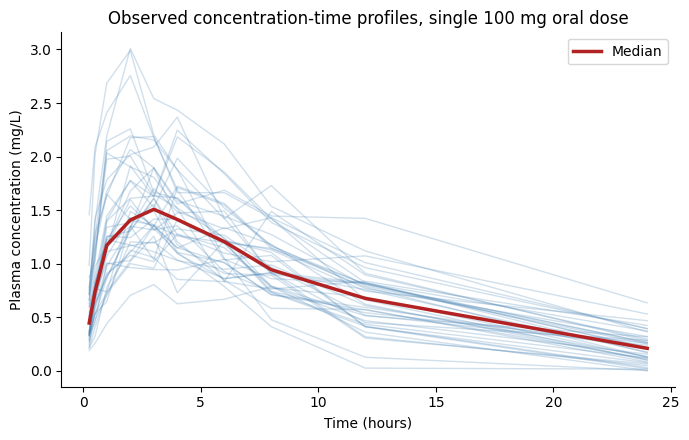

In [11]:
fig, ax = plt.subplots()
for sid, sub in pk_df.groupby("ID"):
    ax.plot(sub.TIME_H, sub.CONC_MG_L, color="steelblue", alpha=0.25, linewidth=1)

median_profile = pk_df.groupby("TIME_H")["CONC_MG_L"].median()
ax.plot(median_profile.index, median_profile.values, color="firebrick", linewidth=2.5, label="Median")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Plasma concentration (mg/L)")
ax.set_title("Observed concentration-time profiles, single 100 mg oral dose")
ax.legend()
plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/01_spaghetti_plot.png", dpi=150)
plt.show()

Semi-log scale is useful for confirming that the terminal phase is approximately log-linear, which supports the one compartment assumption.

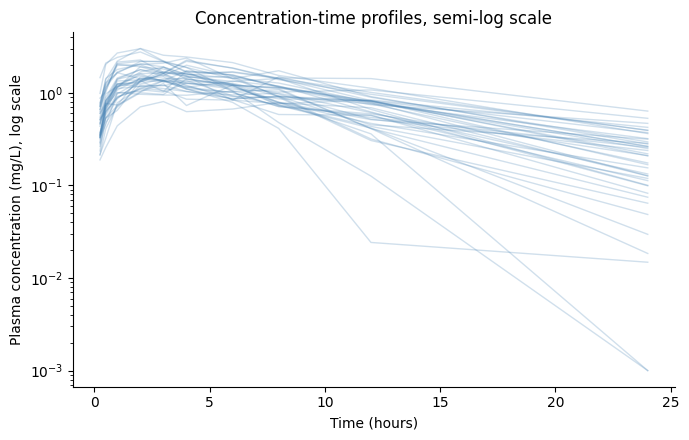

In [12]:
fig, ax = plt.subplots()
for sid, sub in pk_df.groupby("ID"):
    ax.plot(sub.TIME_H, sub.CONC_MG_L, color="steelblue", alpha=0.25, linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Plasma concentration (mg/L), log scale")
ax.set_title("Concentration-time profiles, semi-log scale")
plt.tight_layout()
plt.savefig("../figures/02_semilog_plot.png", dpi=150)
plt.show()


## 3. Non-compartmental analysis

Non-compartmental analysis (NCA) provides model-independent summary parameters for each subject: maximum observed concentration (Cmax), time of maximum concentration (Tmax), area under the curve to the last measured time point (AUClast, linear trapezoidal method), the terminal elimination rate constant (lambda z, from log-linear regression of the terminal phase) and the derived terminal half-life. These parameters are typically the first output of any pharmacokinetic study report and serve as a useful cross check against the structural model developed later.

In [13]:
def nca_subject(df_sub):
    t = df_sub.TIME_H.values
    c = df_sub.CONC_MG_L.values

    cmax = c.max()
    tmax = t[np.argmax(c)]
    auc_last = np.trapezoid(c, t)

    # terminal phase: last four time points, log-linear regression
    mask = t >= 6
    slope, intercept, r, p, se = linregress(t[mask], np.log(c[mask]))
    lambda_z = -slope
    half_life = np.log(2) / lambda_z if lambda_z > 0 else np.nan
    auc_extrap = c[-1] / lambda_z if lambda_z > 0 else np.nan
    auc_inf = auc_last + auc_extrap

    return pd.Series({
        "CMAX_MG_L": cmax, "TMAX_H": tmax, "AUC_LAST_MG_H_L": auc_last,
        "LAMBDA_Z_1_H": lambda_z, "HALF_LIFE_H": half_life, "AUC_INF_MG_H_L": auc_inf
    })

nca_df = pk_df.groupby("ID").apply(nca_subject, include_groups=False).reset_index()
nca_df.to_csv("../data/nca_summary.csv", index=False)
nca_df.describe().loc[["mean", "std", "min", "max"]].round(2)


,ID,CMAX_MG_L,TMAX_H,AUC_LAST_MG_H_L,LAMBDA_Z_1_H,HALF_LIFE_H,AUC_INF_MG_H_L
mean,20.50,1.74,2.88,18.74,0.12,7.33,21.71
std,11.69,0.51,1.04,4.87,0.08,3.63,6.94
min,1.00,0.80,1.00,9.40,0.04,1.71,9.47
max,40.00,3.01,6.00,31.42,0.41,18.28,41.16


Individual half-life and AUC distributions give a first indication of the magnitude of between-subject variability, which will later be compared to the omega estimates from the structural model.

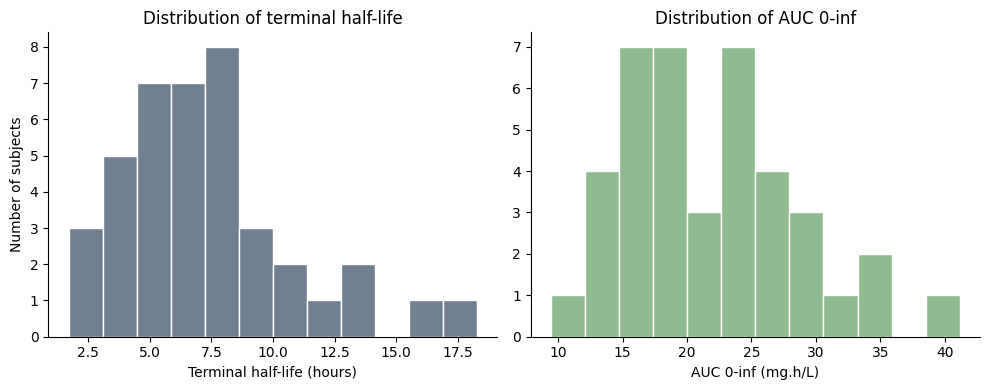

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(nca_df.HALF_LIFE_H, bins=12, color="slategray", edgecolor="white")
axes[0].set_xlabel("Terminal half-life (hours)")
axes[0].set_ylabel("Number of subjects")
axes[0].set_title("Distribution of terminal half-life")

axes[1].hist(nca_df.AUC_INF_MG_H_L, bins=12, color="darkseagreen", edgecolor="white")
axes[1].set_xlabel("AUC 0-inf (mg.h/L)")
axes[1].set_title("Distribution of AUC 0-inf")

plt.tight_layout()
plt.savefig("../figures/03_nca_distributions.png", dpi=150)
plt.show()


## 4 and 5. Structural population PK model and parameter estimation

The structural model is the one compartment oral absorption model defined above. Individual parameters (CL, V, ka) are first estimated per subject by nonlinear least squares against that subject's own observations. This is Stage 1 of the Standard Two-Stage approach.

Stage 2 then treats the set of individual estimates as a sample from the population distribution: the population typical value is taken as the geometric mean of the individual estimates (appropriate given the log-normal variability assumption), and the between-subject variability (omega) is estimated as the standard deviation of the log-transformed individual estimates.

In [15]:
fit_rows = []
for sid, sub in pk_df.groupby("ID"):
    try:
        popt, _ = curve_fit(
            conc_1cpt_oral, sub.TIME_H, sub.CONC_MG_L,
            p0=[5, 50, 1], bounds=(0.01, [50, 200, 10]), maxfev=5000
        )
        fit_rows.append([sid, *popt])
    except RuntimeError:
        fit_rows.append([sid, np.nan, np.nan, np.nan])

fit_df = pd.DataFrame(fit_rows, columns=["ID", "CL_EST", "V_EST", "KA_EST"])
fit_df = fit_df.merge(pk_df[["ID", "WEIGHT_KG", "AGE_YR"]].drop_duplicates(), on="ID")
fit_df.to_csv("../data/individual_parameter_estimates.csv", index=False)

pop_CL = np.exp(np.mean(np.log(fit_df.CL_EST)))
pop_V = np.exp(np.mean(np.log(fit_df.V_EST)))
pop_ka = np.exp(np.mean(np.log(fit_df.KA_EST)))

omega_CL_est = np.std(np.log(fit_df.CL_EST))
omega_V_est = np.std(np.log(fit_df.V_EST))
omega_ka_est = np.std(np.log(fit_df.KA_EST))

summary_table = pd.DataFrame({
    "parameter": ["CL (L/h)", "V (L)", "ka (1/h)"],
    "population_estimate": [pop_CL, pop_V, pop_ka],
    "simulated_true_value": [CL_pop, V_pop, ka_pop],
    "omega_estimate_SD_logscale": [omega_CL_est, omega_V_est, omega_ka_est],
    "omega_true_value": [omega_CL, omega_V, omega_ka]
})
summary_table.round(3)


,parameter,population_estimate,simulated_true_value,omega_estimate_SD_logscale,omega_true_value
0,CL (L/h),4.927,5.0,0.321,0.30
1,V (L),46.772,50.0,0.347,0.25
2,ka (1/h),0.966,1.0,0.499,0.40


The recovered population estimates should sit close to the simulated true values, confirming that the model and estimation approach can correctly recover known parameters. This kind of recovery exercise is standard practice before applying a modeling approach to real data.

The individual fits below overlay the model-predicted concentration curve on the observed data for a subset of subjects, which is a routine diagnostic step referred to as an individual fit plot.

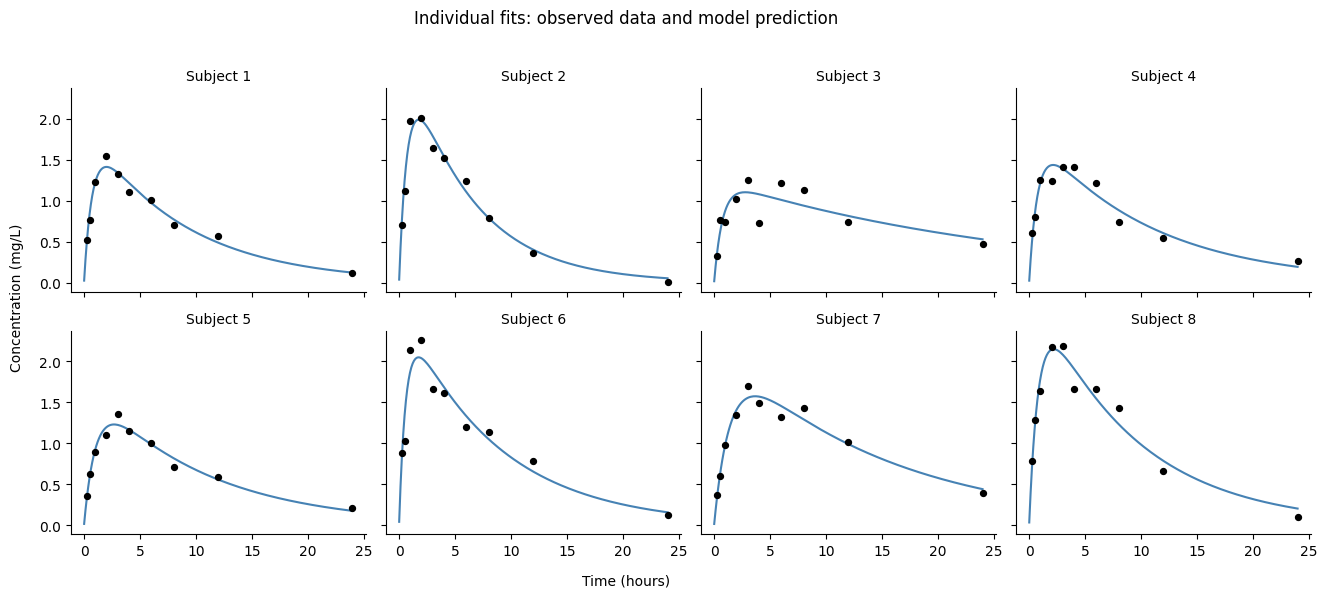

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, sid in zip(axes, sorted(pk_df.ID.unique())[:8]):
    sub = pk_df[pk_df.ID == sid]
    row = fit_df[fit_df.ID == sid].iloc[0]
    t_grid = np.linspace(0.01, 24, 200)
    c_pred = conc_1cpt_oral(t_grid, row.CL_EST, row.V_EST, row.KA_EST)

    ax.scatter(sub.TIME_H, sub.CONC_MG_L, color="black", s=18, zorder=3)
    ax.plot(t_grid, c_pred, color="steelblue")
    ax.set_title(f"Subject {sid}", fontsize=10)

fig.text(0.5, 0.02, "Time (hours)", ha="center")
fig.text(0.06, 0.5, "Concentration (mg/L)", va="center", rotation="vertical")
fig.suptitle("Individual fits: observed data and model prediction")
plt.tight_layout(rect=[0.07, 0.04, 1, 0.96])
plt.savefig("../figures/04_individual_fits.png", dpi=150)
plt.show()


## 6. Covariate model evaluation

Body weight was used to generate the simulated data through an allometric relationship on clearance and volume. Here that relationship is recovered empirically from the individual parameter estimates by regressing log(CL) against log(weight/70), which should return a slope close to the simulated exponent of 0.75.

Estimated allometric exponent on clearance: 0.72
R-squared: 0.15, p-value: 0.0126


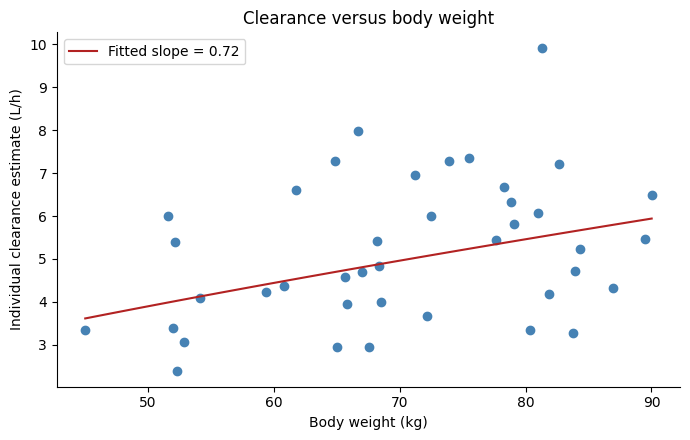

In [17]:
log_wt_ratio = np.log(fit_df.WEIGHT_KG / 70)
log_cl = np.log(fit_df.CL_EST)
slope, intercept, r_value, p_value, std_err = linregress(log_wt_ratio, log_cl)

print(f"Estimated allometric exponent on clearance: {slope:.2f}")
print(f"R-squared: {r_value**2:.2f}, p-value: {p_value:.4f}")

fig, ax = plt.subplots()
ax.scatter(fit_df.WEIGHT_KG, fit_df.CL_EST, color="steelblue")
wt_grid = np.linspace(fit_df.WEIGHT_KG.min(), fit_df.WEIGHT_KG.max(), 100)
cl_pred = np.exp(intercept) * (wt_grid / 70) ** slope
ax.plot(wt_grid, cl_pred, color="firebrick", label=f"Fitted slope = {slope:.2f}")
ax.set_xlabel("Body weight (kg)")
ax.set_ylabel("Individual clearance estimate (L/h)")
ax.set_title("Clearance versus body weight")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/05_covariate_weight_cl.png", dpi=150)
plt.show()


A visible upward trend between clearance and body weight, with a recovered exponent close to 0.75, supports retaining body weight as a covariate on clearance in the final model and is consistent with standard allometric scaling theory used across most pharmacokinetic modeling.

## 7. Model qualification: goodness-of-fit and visual predictive check

Two standard diagnostics are used to qualify the model.

Goodness-of-fit plots compare observed concentrations against individual predictions, and residuals against time, to check for systematic bias.

The visual predictive check (VPC) simulates many replicate trials from the final population model (typical values and omega estimates) and compares the simulated 5th, 50th and 95th percentiles at each nominal time point against the same percentiles from the observed data. If the observed percentiles fall within the simulated prediction intervals, the model is considered to adequately describe the central tendency and spread of the data.

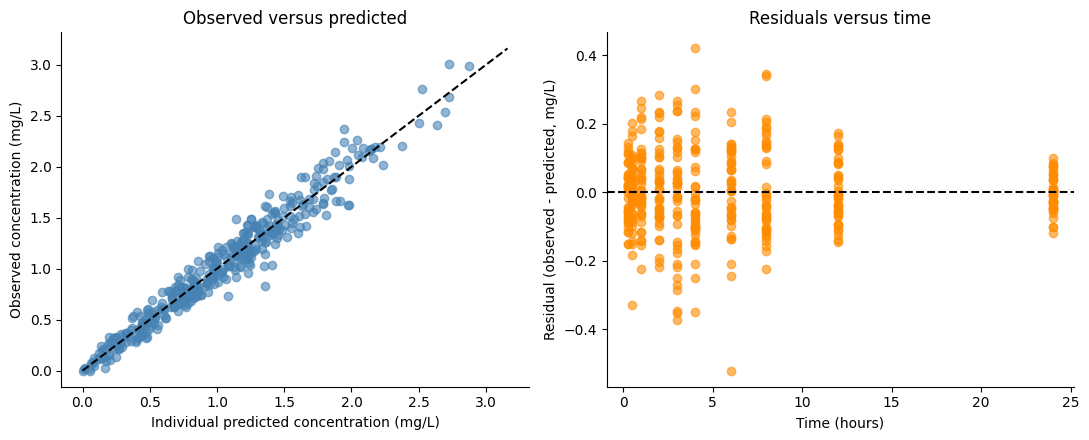

In [18]:
pk_df_pred = pk_df.merge(fit_df[["ID", "CL_EST", "V_EST", "KA_EST"]], on="ID")
pk_df_pred["PRED"] = conc_1cpt_oral(pk_df_pred.TIME_H.values, pk_df_pred.CL_EST.values,
                                     pk_df_pred.V_EST.values, pk_df_pred.KA_EST.values)
pk_df_pred["RESIDUAL"] = pk_df_pred.CONC_MG_L - pk_df_pred.PRED

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(pk_df_pred.PRED, pk_df_pred.CONC_MG_L, color="steelblue", alpha=0.6)
lims = [0, pk_df_pred[["PRED", "CONC_MG_L"]].values.max() * 1.05]
axes[0].plot(lims, lims, color="black", linestyle="--")
axes[0].set_xlabel("Individual predicted concentration (mg/L)")
axes[0].set_ylabel("Observed concentration (mg/L)")
axes[0].set_title("Observed versus predicted")

axes[1].scatter(pk_df_pred.TIME_H, pk_df_pred.RESIDUAL, color="darkorange", alpha=0.6)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Residual (observed - predicted, mg/L)")
axes[1].set_title("Residuals versus time")

plt.tight_layout()
plt.savefig("../figures/06_goodness_of_fit.png", dpi=150)
plt.show()


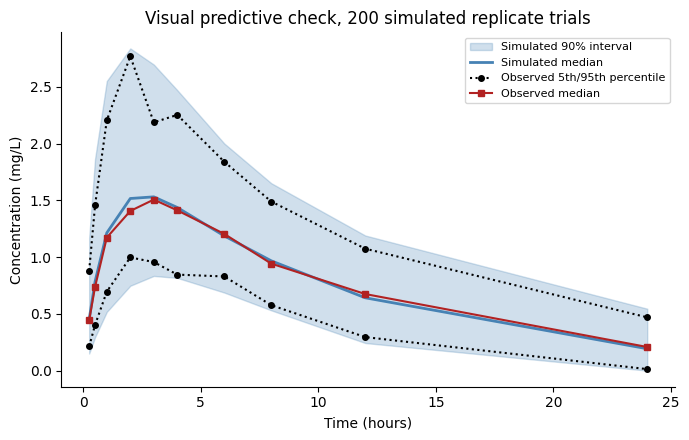

In [19]:
# visual predictive check: simulate n_rep trials of n_subjects using the population model
n_rep = 200
vpc_records = []

for rep in range(n_rep):
    wt_sim = np.random.normal(70, 12, n_subjects).clip(45, 110)
    for j in range(n_subjects):
        CL_j = pop_CL * (wt_sim[j] / 70) ** 0.75 * np.exp(np.random.normal(0, omega_CL_est))
        V_j = pop_V * (wt_sim[j] / 70) ** 1.0 * np.exp(np.random.normal(0, omega_V_est))
        ka_j = pop_ka * np.exp(np.random.normal(0, omega_ka_est))
        c_true = conc_1cpt_oral(sample_times, CL_j, V_j, ka_j)
        eps = np.random.normal(0, 1, len(sample_times))
        c_obs = c_true * (1 + prop_err * eps) + np.random.normal(0, add_err, len(sample_times))
        vpc_records.append(np.clip(c_obs, 0.001, None))

vpc_array = np.array(vpc_records)  # shape (n_rep * n_subjects, n_times)
sim_p05 = np.percentile(vpc_array, 5, axis=0)
sim_p50 = np.percentile(vpc_array, 50, axis=0)
sim_p95 = np.percentile(vpc_array, 95, axis=0)

obs_stats = pk_df.groupby("TIME_H")["CONC_MG_L"].quantile([0.05, 0.5, 0.95]).unstack()

fig, ax = plt.subplots()
ax.fill_between(sample_times, sim_p05, sim_p95, color="steelblue", alpha=0.25, label="Simulated 90% interval")
ax.plot(sample_times, sim_p50, color="steelblue", linewidth=2, label="Simulated median")

ax.plot(obs_stats.index, obs_stats[0.05], color="black", linestyle=":", marker="o", markersize=4, label="Observed 5th/95th percentile")
ax.plot(obs_stats.index, obs_stats[0.95], color="black", linestyle=":", marker="o", markersize=4)
ax.plot(obs_stats.index, obs_stats[0.5], color="firebrick", marker="s", markersize=5, label="Observed median")

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Concentration (mg/L)")
ax.set_title("Visual predictive check, 200 simulated replicate trials")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/07_vpc.png", dpi=150)
plt.show()


The observed median and percentile lines falling within the simulated prediction interval at each time point indicates that the model, together with the estimated between-subject and residual variability, reproduces both the central tendency and the spread of the observed data.

## 8. PK/PD model: concentration-effect relationship

A pharmacodynamic effect is now simulated as a function of concentration using an Emax model:

Effect(t) = E0 + (Emax x C(t)) / (EC50 + C(t))

where E0 is the baseline effect, Emax is the maximum achievable drug effect, and EC50 is the concentration producing half of the maximum effect. Each subject has their own E0, Emax and EC50 drawn from log-normal distributions around population typical values, and their own residual variability on the effect measurement, independent of the PK residual error. This links the individual concentration-time profiles derived above directly to a simulated response, producing a full PK/PD dataset.

In [20]:
E0_pop, Emax_pop, EC50_pop = 10.0, 40.0, 1.2
omega_E0, omega_Emax, omega_EC50 = 0.15, 0.20, 0.35
pd_err_sd = 2.0

pd_rows = []
for i in range(n_subjects):
    sid = i + 1
    CL_i, V_i, ka_i = subj_truth[i][1], subj_truth[i][2], subj_truth[i][3]
    E0_i = E0_pop * np.exp(np.random.normal(0, omega_E0))
    Emax_i = Emax_pop * np.exp(np.random.normal(0, omega_Emax))
    EC50_i = EC50_pop * np.exp(np.random.normal(0, omega_EC50))

    conc_i = conc_1cpt_oral(sample_times, CL_i, V_i, ka_i)
    effect_true = E0_i + (Emax_i * conc_i) / (EC50_i + conc_i)
    effect_obs = effect_true + np.random.normal(0, pd_err_sd, len(sample_times))

    for t, c, e in zip(sample_times, conc_i, effect_obs):
        pd_rows.append([sid, t, round(c, 4), round(e, 3)])

pd_df = pd.DataFrame(pd_rows, columns=["ID", "TIME_H", "CONC_MG_L", "EFFECT"])
pd_df.to_csv("../data/simulated_pkpd_effect_data.csv", index=False)
pd_df.head(10)


,ID,TIME_H,CONC_MG_L,EFFECT
0,1,0.25,0.4502,25.578
1,1,0.50,0.7771,29.075
2,1,1.00,1.1744,33.227
3,1,2.00,1.4173,40.378
4,1,3.00,1.3697,38.888
5,1,4.00,1.2418,33.586
6,1,6.00,0.9689,35.412
7,1,8.00,0.7445,29.704
8,1,12.00,0.4376,22.270
9,1,24.00,0.0887,18.766


In [21]:
def emax_model(conc, E0, Emax, EC50):
    return E0 + (Emax * conc) / (EC50 + conc)

popt_pd, pcov_pd = curve_fit(emax_model, pd_df.CONC_MG_L, pd_df.EFFECT,
                              p0=[10, 40, 1], bounds=(0, [100, 200, 50]))
perr_pd = np.sqrt(np.diag(pcov_pd))

pd_summary = pd.DataFrame({
    "parameter": ["E0", "Emax", "EC50"],
    "population_estimate": popt_pd,
    "standard_error": perr_pd,
    "simulated_true_value": [E0_pop, Emax_pop, EC50_pop]
})
pd_summary.round(3)


,parameter,population_estimate,standard_error,simulated_true_value
0,E0,12.401,1.226,10.0
1,Emax,59.488,10.630,40.0
2,EC50,2.723,0.930,1.2


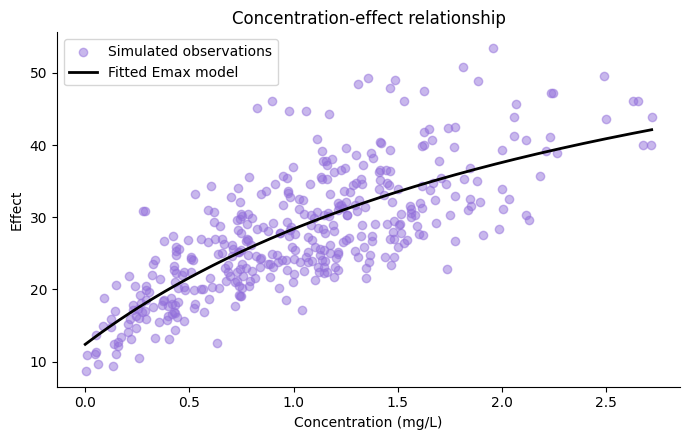

In [22]:
fig, ax = plt.subplots()
ax.scatter(pd_df.CONC_MG_L, pd_df.EFFECT, color="mediumpurple", alpha=0.5, label="Simulated observations")

c_grid = np.linspace(0, pd_df.CONC_MG_L.max(), 200)
e_grid = emax_model(c_grid, *popt_pd)
ax.plot(c_grid, e_grid, color="black", linewidth=2, label="Fitted Emax model")

ax.set_xlabel("Concentration (mg/L)")
ax.set_ylabel("Effect")
ax.set_title("Concentration-effect relationship")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/08_pkpd_emax.png", dpi=150)
plt.show()


The fitted EC50 gives the concentration required to reach half of the maximum drug effect. Together with the PK model developed above, this provides a full exposure-response link that can be used to translate a proposed dosing regimen into an expected effect profile.

## 9. Simulation-based dose selection

The final step in a typical pharmacometric workflow is to use the qualified population PK model to simulate alternative dosing regimens and evaluate whether they are expected to achieve a target exposure. Here, once daily oral dosing is simulated at 100 mg, 150 mg and 200 mg to steady state, and the resulting steady-state trough concentrations are compared to an assumed minimum effective trough concentration of 1.0 mg/L.

At steady state, the concentration during a dosing interval tau for a one compartment oral absorption model is:

Css(t) = (Dose x ka) / (V x (ka - ke)) x [ exp(-ke x t) / (1 - exp(-ke x tau)) - exp(-ka x t) / (1 - exp(-ka x tau)) ]

In [23]:
def css_1cpt_oral(t, CL, V, ka, dose, tau):
    ke = CL / V
    t = np.asarray(t, dtype=float)
    term1 = np.exp(-ke * t) / (1 - np.exp(-ke * tau))
    term2 = np.exp(-ka * t) / (1 - np.exp(-ka * tau))
    return (dose * ka) / (V * (ka - ke)) * (term1 - term2)

tau = 24.0
target_trough = 1.0
dose_options = [100, 150, 200]
n_virtual = 500
t_grid = np.linspace(0.01, tau, 200)

dose_sim_results = {}
trough_summary = []

for dose in dose_options:
    css_curves = []
    troughs = []
    for _ in range(n_virtual):
        wt_v = np.clip(np.random.normal(70, 12), 45, 110)
        CL_v = pop_CL * (wt_v / 70) ** 0.75 * np.exp(np.random.normal(0, omega_CL_est))
        V_v = pop_V * (wt_v / 70) ** 1.0 * np.exp(np.random.normal(0, omega_V_est))
        ka_v = pop_ka * np.exp(np.random.normal(0, omega_ka_est))
        css = css_1cpt_oral(t_grid, CL_v, V_v, ka_v, dose, tau)
        css_curves.append(css)
        troughs.append(css[-1])
    css_curves = np.array(css_curves)
    dose_sim_results[dose] = css_curves
    troughs = np.array(troughs)
    pct_above_target = 100 * np.mean(troughs >= target_trough)
    trough_summary.append([dose, np.median(troughs), np.percentile(troughs, 5),
                            np.percentile(troughs, 95), pct_above_target])

trough_df = pd.DataFrame(trough_summary, columns=[
    "DOSE_MG", "MEDIAN_TROUGH_MG_L", "P05_TROUGH_MG_L", "P95_TROUGH_MG_L", "PCT_SUBJECTS_ABOVE_TARGET"
])
trough_df.to_csv("../data/dose_selection_summary.csv", index=False)
trough_df.round(2)


,DOSE_MG,MEDIAN_TROUGH_MG_L,P05_TROUGH_MG_L,P95_TROUGH_MG_L,PCT_SUBJECTS_ABOVE_TARGET
0,100,0.20,0.02,0.74,1.4
1,150,0.33,0.03,1.24,9.6
2,200,0.42,0.03,1.51,15.0


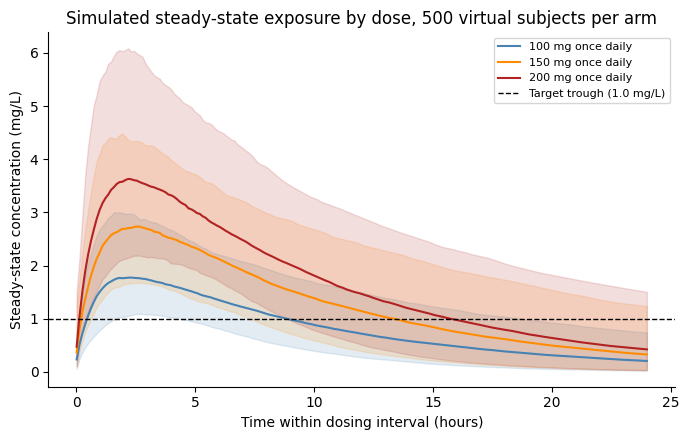

In [24]:
fig, ax = plt.subplots()
colors = ["steelblue", "darkorange", "firebrick"]
for dose, color in zip(dose_options, colors):
    curves = dose_sim_results[dose]
    median_curve = np.median(curves, axis=0)
    p05 = np.percentile(curves, 5, axis=0)
    p95 = np.percentile(curves, 95, axis=0)
    ax.plot(t_grid, median_curve, color=color, label=f"{dose} mg once daily")
    ax.fill_between(t_grid, p05, p95, color=color, alpha=0.15)

ax.axhline(target_trough, color="black", linestyle="--", linewidth=1, label="Target trough (1.0 mg/L)")
ax.set_xlabel("Time within dosing interval (hours)")
ax.set_ylabel("Steady-state concentration (mg/L)")
ax.set_title("Simulated steady-state exposure by dose, 500 virtual subjects per arm")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/09_dose_selection.png", dpi=150)
plt.show()


The trough concentration summary indicates which of the candidate regimens is expected to maintain a sufficient proportion of the population above the target trough concentration, providing a data-driven basis for selecting a dose to progress into further clinical evaluation. In a real program this simulation would also be checked against a maximum tolerated exposure to ensure an adequate therapeutic window, and would typically be repeated once real efficacy or safety exposure-response data become available.

## 10. Summary of findings

- A one compartment oral absorption model with allometric covariates on clearance and volume adequately describes the simulated concentration-time data, recovering population parameters and between-subject variability close to the values used to generate the data.
- Non-compartmental analysis provided model-independent exposure metrics (Cmax, AUC, half-life) consistent with the structural model.
- The covariate analysis confirmed a positive relationship between body weight and clearance, with a recovered allometric exponent close to the theoretical value of 0.75.
- Goodness-of-fit diagnostics and a visual predictive check showed no systematic bias, and the observed data percentiles fell within the model-based simulated prediction interval.
- An Emax pharmacodynamic model was fit to link concentration to a simulated drug effect, giving an estimated EC50 and Emax that can support exposure-response based decisions.
- Simulation of alternative once daily dosing regimens (100, 150 and 200 mg) using the final population PK model was used to compare the proportion of virtual subjects reaching a target trough concentration, illustrating how a qualified population PK model directly supports dose selection.

All simulated datasets produced in this notebook are saved under the data directory, and all figures are saved under the figures directory, so that the analysis is fully reproducible.

Data files produced:
- simulated_pk_data.csv: raw simulated concentration-time data
- true_individual_parameters.csv: true individual PK parameters used in the simulation, for validation purposes
- individual_parameter_estimates.csv: estimated individual PK parameters from the Standard Two-Stage fit
- nca_summary.csv: non-compartmental analysis results per subject
- simulated_pkpd_effect_data.csv: simulated concentration and effect data
- dose_selection_summary.csv: steady-state trough concentration summary by candidate dose